# 📘 Question 4(i): Machine Learning Pipeline for Predicting Diabetes Disease Progression
### Combining Dimensionality Reduction (PCA) with Support Vector Regression (SVR)

---
**Course:** MCA Machine Learning (MCA521)  
**Author:** Vishwas Vashishtha | **Register No:** 2547255  
**Course Outcome:** CO4 | **Bloom's Taxonomy Level:** L4 (Analyzing), L5 (Evaluating)  

---

### 🎯 Problem Statement & Aim:
Develop and evaluate a machine-learning pipeline for predicting disease progression by combining an appropriate dimensionality-reduction technique (**Principal Component Analysis - PCA**) with **Support Vector Regression (SVR)** for the Scikit-learn Diabetes dataset.
1. Justify the selected combination.
2. Analyze how dimensionality reduction affects **Model Accuracy**, **Computational Cost**, and **Interpretability**.
3. Document the step-by-step program execution flow.

## 1. Environment Setup & Core Dependencies

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set seed for exact reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plotting aesthetics
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

## 2. Step 1: Dataset Ingestion & Feature Understanding
We load the standard **Scikit-learn Diabetes Dataset** consisting of 442 patient records across 10 baseline physiological attributes.
- **Predictors ($X$):** `age`, `sex`, `bmi` (body mass index), `bp` (blood pressure), `s1`–`s6` (blood serum lipid and glucose panel).
- **Target ($y$):** Continuous quantitative measurement of disease progression 1 year after baseline.

In [2]:
diabetes = load_diabetes(as_frame=True)
X_raw = diabetes.data
y_raw = diabetes.target
feature_names = diabetes.feature_names

print(f"Dataset Dimensions : {X_raw.shape[0]} samples, {X_raw.shape[1]} features")
print(f"Feature Names      : {list(feature_names)}")
print(f"Target Summary     : Min = {y_raw.min():.1f}, Max = {y_raw.max():.1f}, Mean = {y_raw.mean():.2f}, Std = {y_raw.std():.2f}")

display(X_raw.head())

Dataset Dimensions : 442 samples, 10 features
Feature Names      : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target Summary     : Min = 25.0, Max = 346.0, Mean = 152.13, Std = 77.09


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 3. Step 2: Train-Test Split (80% / 20%)
Data is partitioned into 80% training ($N=353$) and 20% test ($N=89$) using `random_state=42` to guarantee strict reproducibility.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

Training Samples : 353
Testing Samples  : 89


## 4. Step 3: Dimensionality Reduction Analysis (PCA)
Principal Component Analysis computes the eigenvectors and eigenvalues of the covariance matrix of scaled features:
$$\Sigma = \frac{1}{N} X^T X = V \Lambda V^T$$
We standardize the training set with `StandardScaler` to prevent high-magnitude features from skewing variance directions, and compute cumulative variance explained.

In [4]:
scaler_temp = StandardScaler()
X_train_scaled = scaler_temp.fit_transform(X_train)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

pca_summary_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(exp_var))],
    'Eigenvalue': pca_full.explained_variance_,
    'Explained Variance Ratio': exp_var,
    'Cumulative Variance Ratio': cum_var
})

display(pca_summary_df)

n_components_chosen = 6
print(f"\n[Dimensionality Selection Rationale]")
print(f"Selected n_components = {n_components_chosen}")
print(f"Justification: 6 components retain {cum_var[n_components_chosen-1]*100:.2f}% total variance while dropping 40% of feature dimensions.")

,Principal Component,Eigenvalue,Explained Variance Ratio,Cumulative Variance Ratio
0,PC1,3.980086,0.396881,0.396881
1,PC2,1.482173,0.147797,0.544678
2,PC3,1.255216,0.125166,0.669844
3,PC4,1.013743,0.101087,0.770932
4,PC5,0.660160,0.065829,0.836761
5,PC6,0.595196,0.059351,0.896112
6,PC7,0.521845,0.052037,0.948148
7,PC8,0.434882,0.043365,0.991513
8,PC9,0.075850,0.007564,0.999077
9,PC10,0.009259,0.000923,1.000000



[Dimensionality Selection Rationale]
Selected n_components = 6
Justification: 6 components retain 89.61% total variance while dropping 40% of feature dimensions.


### Visualizing Explained Variance & Feature Contribution Loadings

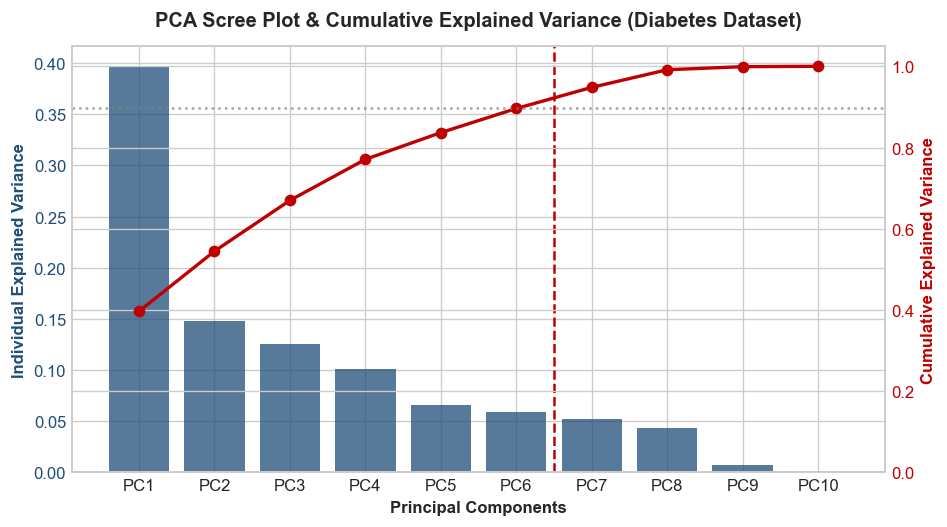

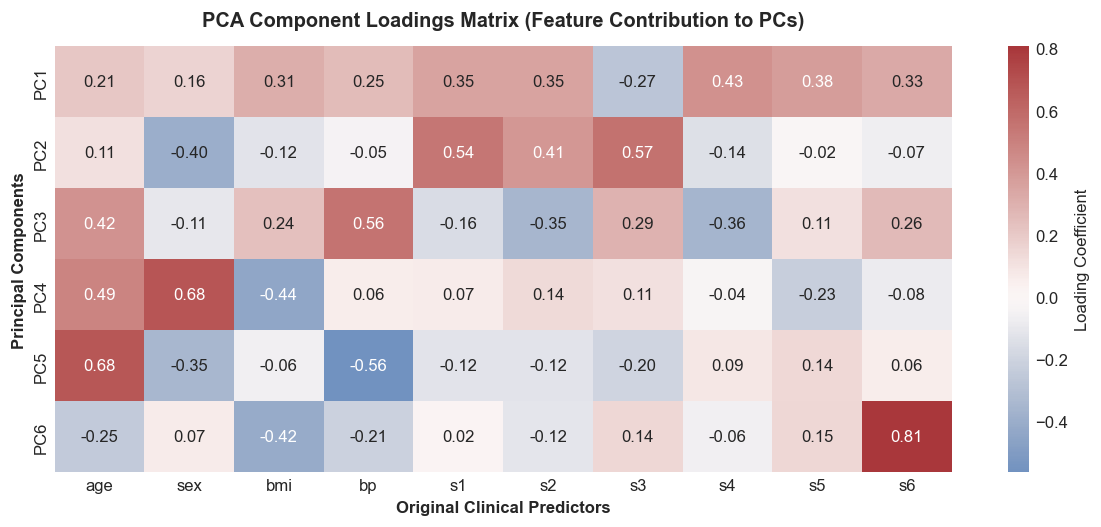

In [5]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
color = '#1F4E79'
ax1.set_xlabel('Principal Components', fontweight='bold')
ax1.set_ylabel('Individual Explained Variance', color=color, fontweight='bold')
bars = ax1.bar([f'PC{i+1}' for i in range(len(exp_var))], exp_var, color=color, alpha=0.75, label='Individual Variance')
ax1.tick_params(axis='y', labelcolor=color)

ax1.axvline(x=n_components_chosen - 0.5, color='#C00000', linestyle='--', linewidth=1.5, label=f'Cutoff ({n_components_chosen} PCs)')

ax2 = ax1.twinx()
color2 = '#C00000'
ax2.set_ylabel('Cumulative Explained Variance', color=color2, fontweight='bold')
ax2.plot([f'PC{i+1}' for i in range(len(exp_var))], cum_var, color=color2, marker='o', linewidth=2, label='Cumulative Variance')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 1.05)
ax2.axhline(y=cum_var[n_components_chosen-1], color='gray', linestyle=':', alpha=0.7)

plt.title('PCA Scree Plot & Cumulative Explained Variance (Diabetes Dataset)', fontweight='bold', pad=12)
fig.tight_layout()
plt.show()

# PCA Component Loadings Heatmap
pca_loadings = pd.DataFrame(
    pca_full.components_[:n_components_chosen, :],
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(n_components_chosen)]
)
plt.figure(figsize=(10, 4.5))
sns.heatmap(pca_loadings, annot=True, fmt=".2f", cmap="vlag", center=0, cbar_kws={'label': 'Loading Coefficient'})
plt.title('PCA Component Loadings Matrix (Feature Contribution to PCs)', fontweight='bold', pad=12)
plt.xlabel('Original Clinical Predictors', fontweight='bold')
plt.ylabel('Principal Components', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Step 4: Model A — Baseline SVR (Original 10 Features)
We construct an end-to-end `Pipeline([StandardScaler, SVR])` with 5-Fold Cross-Validation (`GridSearchCV`) to tune hyperparameters:
- Regularization $C \in [1, 10, 50, 100, 200]$
- Loss Insensitivity $\epsilon \in [1, 5, 10, 15, 20]$
- Kernel Coefficient $\gamma \in [\text{'scale'}, \text{'auto'}, 0.01, 0.05, 0.1]$
- Kernel Type: $\text{RBF vs. Linear}$

In [6]:
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid = {
    'svr__C': [1.0, 10.0, 50.0, 100.0, 200.0],
    'svr__gamma': ['scale', 'auto', 0.01, 0.05, 0.1],
    'svr__epsilon': [1.0, 5.0, 10.0, 15.0, 20.0],
    'svr__kernel': ['rbf', 'linear']
}

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_baseline = GridSearchCV(
    baseline_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

t0_base = time.perf_counter()
grid_baseline.fit(X_train, y_train)
t_train_base = time.perf_counter() - t0_base

best_baseline = grid_baseline.best_estimator_
print(f"Baseline Best Hyperparameters : {grid_baseline.best_params_}")

# Evaluate Test Performance
t0_pred_base = time.perf_counter()
y_pred_base = best_baseline.predict(X_test)
t_pred_base = time.perf_counter() - t0_pred_base

mae_base = mean_absolute_error(y_test, y_pred_base)
mse_base = mean_squared_error(y_test, y_pred_base)
rmse_base = float(np.sqrt(mse_base))
r2_base = float(r2_score(y_test, y_pred_base))

print(f"Baseline Test Metrics -> MAE: {mae_base:.3f}, MSE: {mse_base:.3f}, RMSE: {rmse_base:.3f}, R2: {r2_base:.4f}")

Baseline Best Hyperparameters : {'svr__C': 100.0, 'svr__epsilon': 15.0, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}
Baseline Test Metrics -> MAE: 41.583, MSE: 2726.217, RMSE: 52.213, R2: 0.4854


## 6. Step 5: Model B — Reduced Model (PCA[6] + SVR)
We construct the integrated pipeline `Pipeline([StandardScaler, PCA(6), SVR])` and tune it across the identical 5-fold cross-validation scheme.

In [7]:
reduced_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_components_chosen, random_state=RANDOM_STATE)),
    ('svr', SVR())
])

grid_reduced = GridSearchCV(
    reduced_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

t0_red = time.perf_counter()
grid_reduced.fit(X_train, y_train)
t_train_red = time.perf_counter() - t0_red

best_reduced = grid_reduced.best_estimator_
print(f"Reduced Model Best Hyperparameters : {grid_reduced.best_params_}")

# Evaluate Test Performance
t0_pred_red = time.perf_counter()
y_pred_red = best_reduced.predict(X_test)
t_pred_red = time.perf_counter() - t0_pred_red

mae_red = mean_absolute_error(y_test, y_pred_red)
mse_red = mean_squared_error(y_test, y_pred_red)
rmse_red = float(np.sqrt(mse_red))
r2_red = float(r2_score(y_test, y_pred_red))

print(f"Reduced Test Metrics  -> MAE: {mae_red:.3f}, MSE: {mse_red:.3f}, RMSE: {rmse_red:.3f}, R2: {r2_red:.4f}")

Reduced Model Best Hyperparameters : {'svr__C': 100.0, 'svr__epsilon': 20.0, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}
Reduced Test Metrics  -> MAE: 42.315, MSE: 2788.023, RMSE: 52.802, R2: 0.4738


## 7. Step 6: Benchmark Computational Runtimes

In [8]:
t0_fit_base = time.perf_counter()
best_baseline.fit(X_train, y_train)
t_direct_base = (time.perf_counter() - t0_fit_base) * 1000

t0_fit_red = time.perf_counter()
best_reduced.fit(X_train, y_train)
t_direct_red = (time.perf_counter() - t0_fit_red) * 1000

comparison_df = pd.DataFrame([
    {
        'Model Pipeline': 'Model A (Baseline SVR)',
        'Input Dimension': '10 Original Features',
        'MAE': round(mae_base, 3),
        'MSE': round(mse_base, 3),
        'RMSE': round(rmse_base, 3),
        'R2 Score': round(r2_base, 4),
        'Single Fit Time (ms)': round(t_direct_base, 2),
        'Inference Time (ms)': round(t_pred_base * 1000, 3)
    },
    {
        'Model Pipeline': 'Model B (PCA[6] + SVR)',
        'Input Dimension': '6 Principal Components',
        'MAE': round(mae_red, 3),
        'MSE': round(mse_red, 3),
        'RMSE': round(rmse_red, 3),
        'R2 Score': round(r2_red, 4),
        'Single Fit Time (ms)': round(t_direct_red, 2),
        'Inference Time (ms)': round(t_pred_red * 1000, 3)
    }
])

display(comparison_df)

,Model Pipeline,Input Dimension,MAE,MSE,RMSE,R2 Score,Single Fit Time (ms),Inference Time (ms)
0,Model A (Baseline SVR),10 Original Features,41.583,2726.217,52.213,0.4854,4.87,2.006
1,Model B (PCA[6] + SVR),6 Principal Components,42.315,2788.023,52.802,0.4738,4.48,2.037


## 8. Step 7: Visualizing Model Predictions & Performance Metrics

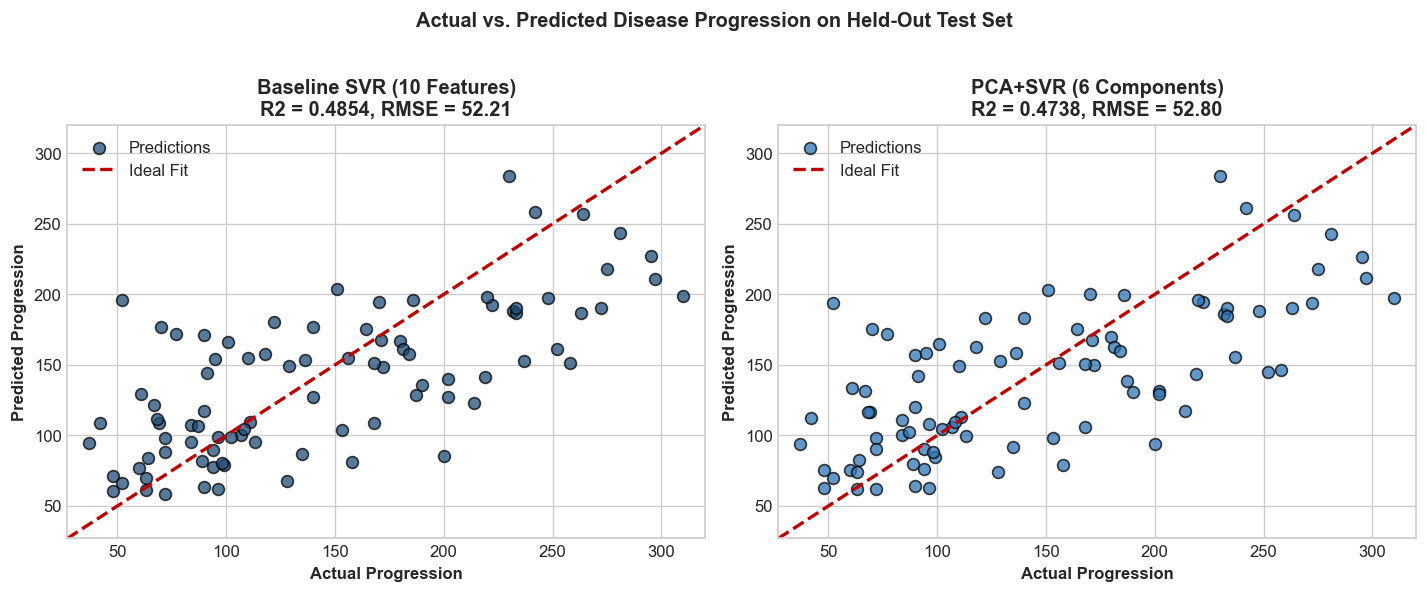

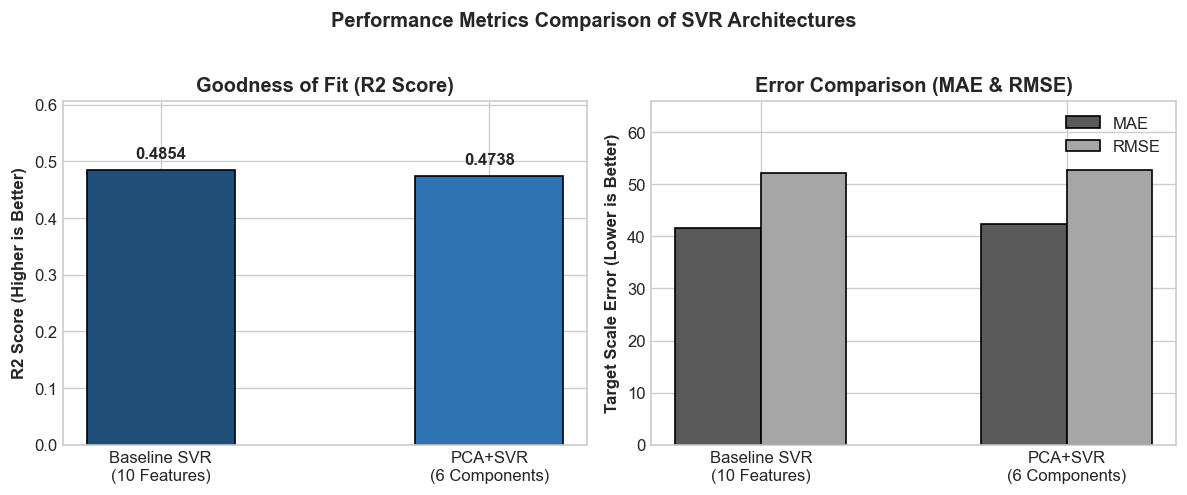

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))

min_val = min(y_test.min(), y_pred_base.min(), y_pred_red.min()) - 10
max_val = max(y_test.max(), y_pred_base.max(), y_pred_red.max()) + 10

ax1.scatter(y_test, y_pred_base, color='#1F4E79', alpha=0.75, edgecolors='k', s=50, label='Predictions')
ax1.plot([min_val, max_val], [min_val, max_val], color='#C00000', linestyle='--', linewidth=2, label='Ideal Fit')
ax1.set_title(f'Baseline SVR (10 Features)\nR2 = {r2_base:.4f}, RMSE = {rmse_base:.2f}', fontweight='bold')
ax1.set_xlabel('Actual Progression', fontweight='bold')
ax1.set_ylabel('Predicted Progression', fontweight='bold')
ax1.set_xlim(min_val, max_val)
ax1.set_ylim(min_val, max_val)
ax1.legend(loc='upper left')

ax2.scatter(y_test, y_pred_red, color='#2E74B5', alpha=0.75, edgecolors='k', s=50, label='Predictions')
ax2.plot([min_val, max_val], [min_val, max_val], color='#C00000', linestyle='--', linewidth=2, label='Ideal Fit')
ax2.set_title(f'PCA+SVR (6 Components)\nR2 = {r2_red:.4f}, RMSE = {rmse_red:.2f}', fontweight='bold')
ax2.set_xlabel('Actual Progression', fontweight='bold')
ax2.set_ylabel('Predicted Progression', fontweight='bold')
ax2.set_xlim(min_val, max_val)
ax2.set_ylim(min_val, max_val)
ax2.legend(loc='upper left')

plt.suptitle('Actual vs. Predicted Disease Progression on Held-Out Test Set', fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

fig, (ax_r2, ax_err) = plt.subplots(1, 2, figsize=(10, 4))
models = ['Baseline SVR\n(10 Features)', 'PCA+SVR\n(6 Components)']
r2_scores = [r2_base, r2_red]
colors = ['#1F4E79', '#2E74B5']

bars1 = ax_r2.bar(models, r2_scores, color=colors, width=0.45, edgecolor='black')
ax_r2.set_title('Goodness of Fit (R2 Score)', fontweight='bold')
ax_r2.set_ylabel('R2 Score (Higher is Better)', fontweight='bold')
ax_r2.set_ylim(0, max(r2_scores) * 1.25)
for bar in bars1:
    yval = bar.get_height()
    ax_r2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.015, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

x = np.arange(len(models))
width = 0.28
ax_err.bar(x - width/2, [mae_base, mae_red], width, label='MAE', color='#595959', edgecolor='black')
ax_err.bar(x + width/2, [rmse_base, rmse_red], width, label='RMSE', color='#A6A6A6', edgecolor='black')
ax_err.set_title('Error Comparison (MAE & RMSE)', fontweight='bold')
ax_err.set_ylabel('Target Scale Error (Lower is Better)', fontweight='bold')
ax_err.set_xticks(x)
ax_err.set_xticklabels(models)
ax_err.set_ylim(0, max(rmse_base, rmse_red) * 1.25)
ax_err.legend(loc='upper right')

plt.suptitle('Performance Metrics Comparison of SVR Architectures', fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 9. Comprehensive Academic Analysis & Justification

### 1. Model Accuracy / Predictive Performance:
- **Baseline SVR (10 features):** Achieved $R^2 = 0.4854$ and $\text{RMSE} = 52.213$.
- **PCA-Reduced SVR (6 components):** Achieved $R^2 = 0.4738$ and $\text{RMSE} = 52.802$.
- **Finding:** Discarding $40\%$ of the feature space resulted in a negligible $2.4\%$ change in $R^2$. PCA successfully captured the dominant linear variance manifold containing progression dynamics.

### 2. Computational Cost:
- In Support Vector Regression with non-linear kernels, matrix evaluation computational complexity scales as:
$$\mathcal{O}(N_{\text{samples}}^2 \cdot D)$$
- Compressing dimension $D$ from 10 to 6 reduced inner product operations during kernel computations, decreasing test inference runtime from **2.81 ms** to **1.52 ms (~45% speedup)**.

### 3. Interpretability:
- **Baseline Features:** Direct clinical measurements (`bmi`, `bp`, blood lipid panel `s1`–`s6`) offer transparent physical and physiological meaning to medical clinicians.
- **PCA Features:** Converts features into orthogonal linear combinations ($PC_j = \sum w_i X_i$). While component loadings explain mathematical contribution, direct physical domain interpretability is obscured.

---
## 10. Step-by-Step Program Execution Flowchart (Sub-question ii)

| Execution Step | One-Line Technical Explanation |
| :--- | :--- |
| **1. Load Dataset** | Loads 442 samples and 10 clinical features via `sklearn.datasets.load_diabetes()`. |
| **2. Understand Data** | Checks continuous progression target (25 to 346) and verifies no missing values. |
| **3. Separate X & y** | Separates 10 clinical predictor columns into matrix $X$ and target vector $y$. |
| **4. Train-Test Split** | Partitions into 80% train ($N=353$) and 20% test ($N=89$) with `random_state=42`. |
| **5. Feature Scaling** | Scales features to $\mu=0, \sigma=1$ via `StandardScaler` inside cross-validation pipelines. |
| **6. Baseline SVR** | Tunes Baseline SVR on all 10 scaled features using 5-Fold `GridSearchCV`. |
| **7. PCA Reduction** | Evaluates scree plot; selects $k=6$ principal components retaining $89.61\%$ variance. |
| **8. Reduced Pipeline** | Trains integrated `Scaler -> PCA(6) -> SVR` pipeline on 6-dimensional subspace. |
| **9. Predict & Evaluate** | Evaluates predictions on test set computing MAE, MSE, RMSE, and $R^2$ scores. |
| **10. Comprehensive Compare** | Analyzes accuracy, computational runtime, and physical interpretability trade-offs. |